In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [47]:

#import kagglehub
# You may need to re-run this cell after logging in.
#kagglehub.login()
#path = kagglehub.competition_download('store-sales-time-series-forecasting')
#-----------------------
#Already Downloaded So will be using the download from Drive
path = '/content/drive/MyDrive/SalesTimeSeries/store-sales-time-series-forecasting'


In [48]:
df_train = pd.read_csv(path+'/train.csv')
df_stores = pd.read_csv(path+'/stores.csv')
df_oil = pd.read_csv(path+'/oil.csv')

In [49]:
df_train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [50]:
df_stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [51]:
df_oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [52]:
df_train.groupby('date').head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
...,...,...,...,...,...,...
2999106,2999106,2017-08-15,1,AUTOMOTIVE,4.0,0
2999107,2999107,2017-08-15,1,BABY CARE,0.0,0
2999108,2999108,2017-08-15,1,BEAUTY,4.0,1
2999109,2999109,2017-08-15,1,BEVERAGES,1942.0,11


# Part 1 EDA
Things to do:


1. Plot total sales aggregated by day across the entire dataset. What patterns do you see — trend, seasonality, anomalies?

2. Merge oil.csv into the training data. Oil price has significant missing values — how do you handle them and why?

3. Pick one store and one product family. Plot its sales over time. Does it follow the overall trend or deviate?

/tmp/ipykernel_36003/2355660905.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_temp['sales'].resample('M').sum()


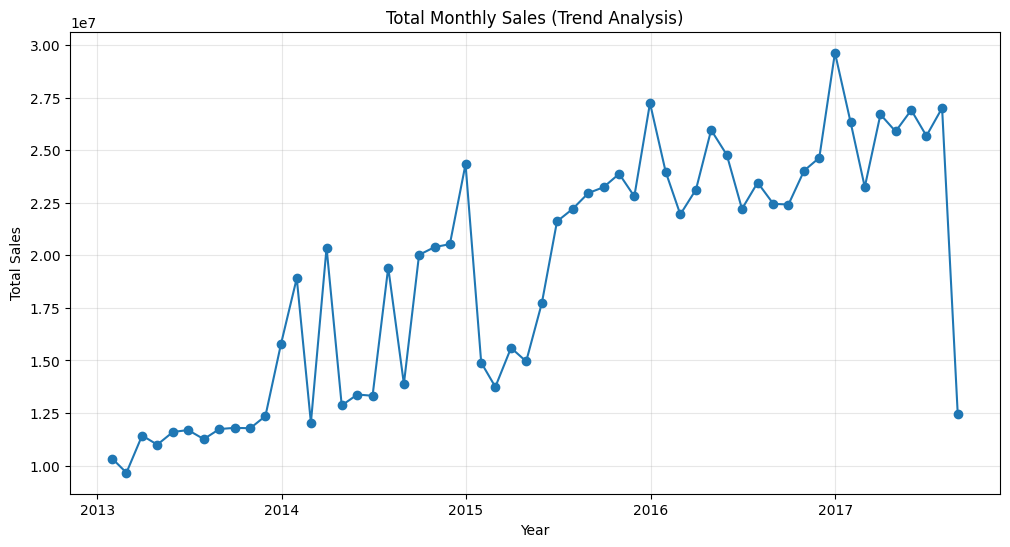

In [53]:
df_train['date'] = pd.to_datetime(df_train['date'])

# Set date as index to allow resampling
df_temp = df_train.set_index('date')

# Resample to Monthly ('M') and sum the sales
monthly_sales = df_temp['sales'].resample('M').sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title("Total Monthly Sales (Trend Analysis)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.show()

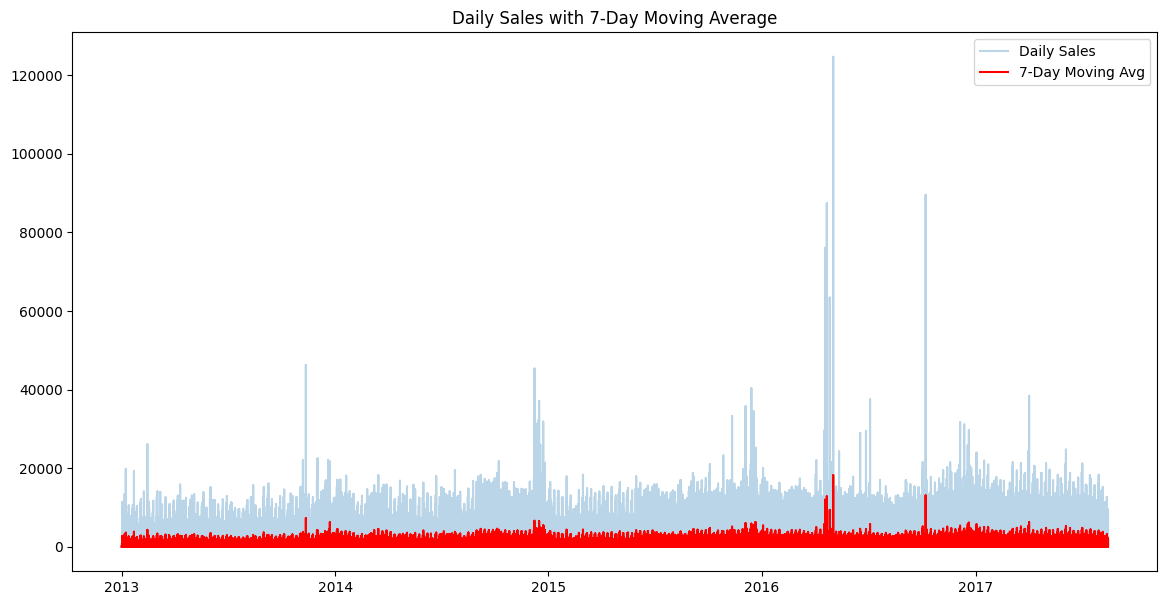

In [54]:
# Calculate a 7-day rolling average
df_train['sales_moving_avg'] = df_train['sales'].rolling(window=7).mean()

plt.figure(figsize=(14, 7))
plt.plot(df_train['date'], df_train['sales'], alpha=0.3, label='Daily Sales') # Faded original
plt.plot(df_train['date'], df_train['sales_moving_avg'], color='red', label='7-Day Moving Avg')
plt.title("Daily Sales with 7-Day Moving Average")
plt.legend()
plt.show()

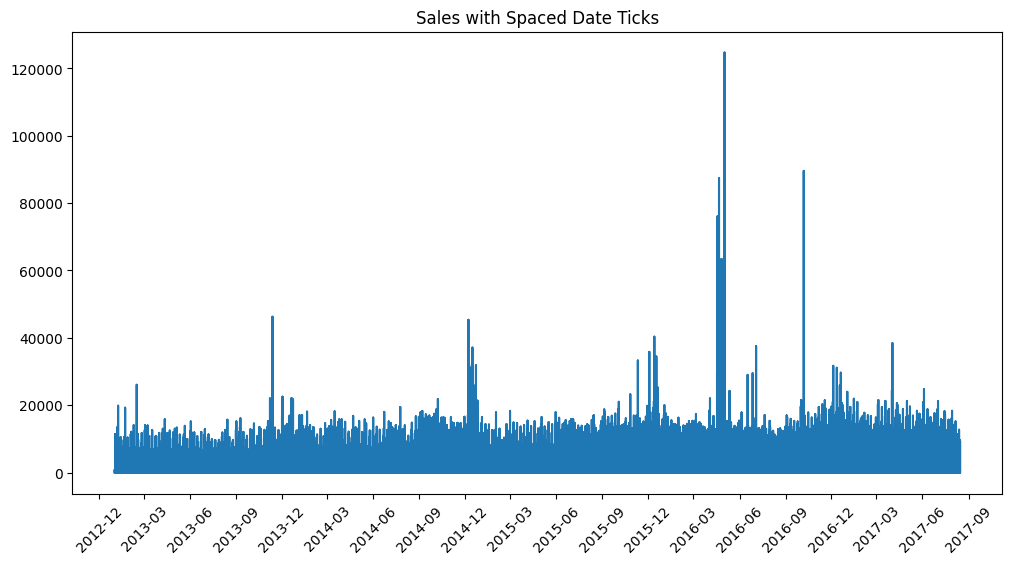

In [55]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_train['date'], df_train['sales'])

# Show a tick every 3 months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# Format the date as 'Year-Month'
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.title("Sales with Spaced Date Ticks")
plt.show()

Handling the missing data in the oil Dataset by giving it the mean for each day as the oill campanies change their work at holidays

Merging the training data with the cleaned oil data

In [56]:

df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].fillna(df_oil['dcoilwtico'].rolling(7, min_periods=1).mean())
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].fillna(df_oil['dcoilwtico'].mean())
df_merged =  pd.merge(df_train,df_oil,on='date',how='left')
df_merged.head()

,id,date,store_nbr,family,sales,onpromotion,sales_moving_avg,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,67.662714
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,67.662714
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,67.662714
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,67.662714
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,67.662714


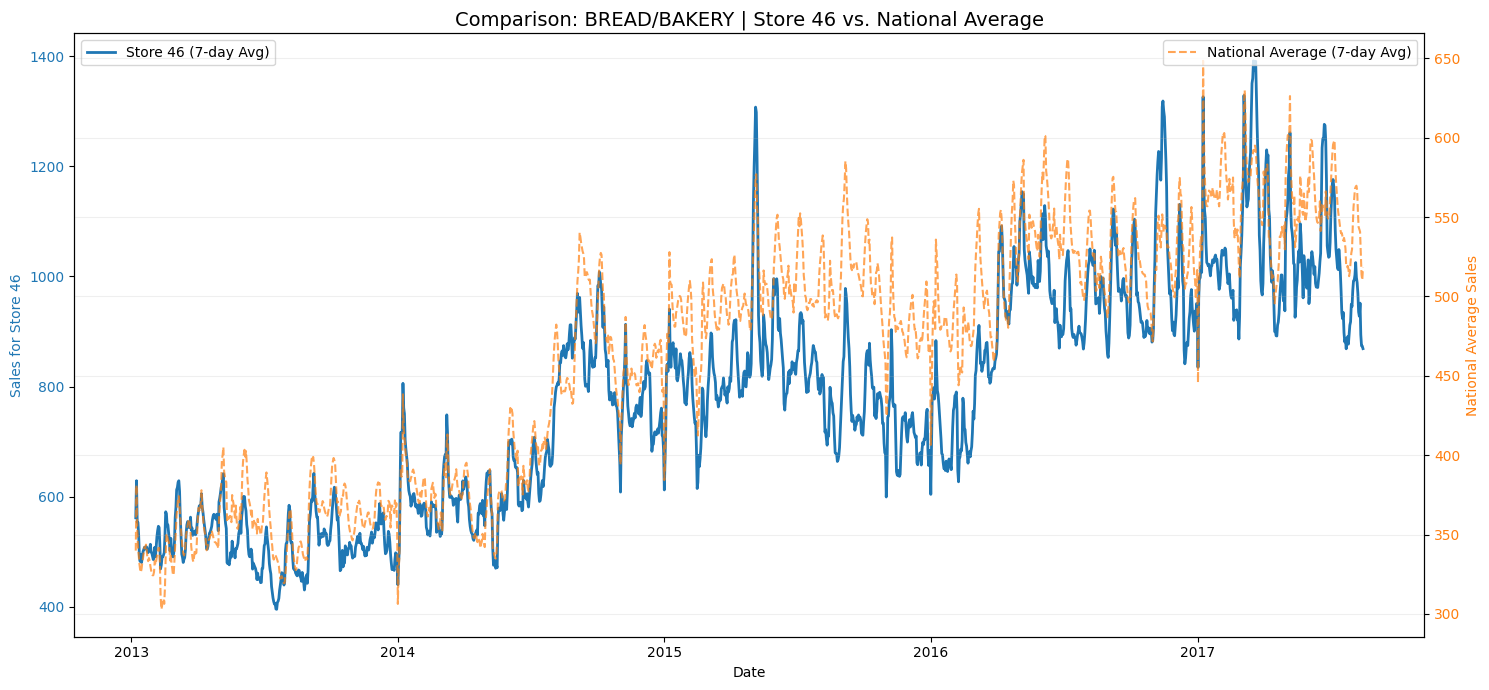

Comparing BREAD/BAKERY in Store 46 against the National Mean.


In [57]:

# 1. Selection
random_store = np.random.choice(df_merged['store_nbr'].unique())
random_family = np.random.choice(df_merged['family'].unique())

# 2. Filter: Single Store/Family
store_data = df_merged[(df_merged['store_nbr'] == random_store) &
                       (df_merged['family'] == random_family)].copy()
store_data = store_data.groupby('date')['sales'].sum().rolling(window=7).mean()

# 3. Filter: National Average for that same Family
national_avg = df_merged[df_merged['family'] == random_family].groupby('date')['sales'].mean()
national_avg = national_avg.rolling(window=7).mean()

# 4. Plotting with twin axes because scales differ
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Store Data
ax1.plot(store_data.index, store_data.values, color='tab:blue', label=f'Store {random_store} (7-day Avg)', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel(f'Sales for Store {random_store}', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create secondary axis for National Average
ax2 = ax1.twinx()
ax2.plot(national_avg.index, national_avg.values, color='tab:orange', label='National Average (7-day Avg)', linestyle='--', alpha=0.7)
ax2.set_ylabel('National Average Sales', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f"Comparison: {random_family} | Store {random_store} vs. National Average", fontsize=14)
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

print(f"Comparing {random_family} in Store {random_store} against the National Mean.")

some follow while other don't follow

My way of thinking to see (overall trend) is see that family along all other stores



# Feature Engineering

It will be specifc about time series
I will be making


1.  Calender features

    1. Day of the week (important because of weekly seasonality as some people might be pursharing more in of Friday which might be affecting the sales)
    2. Month (some months might be more important than others because of summer vacations or seasonal changes of temperture)
    3. Year to make the model understand the model going upward
    4. Weekend (Some people might just buy in the weekends only)
    
2.  Lag Features
    1. lag_7: Last week's exact same day. (captures a relation between the same day as the day in the last week)

    2. lag_price_diff: Difference between current oil price and 7-day average oil price.


1.  Rolling Window
     
    1. rolling_mean_7: Average of the last week (captures immediate trend).

    2. rolling_mean_30: Average of the last month (captures long-term store health).

2.   rolling window from oil





In [58]:
# 1. Day of Week (0=Monday, 6=Sunday)
df_merged['day_of_week'] = df_merged['date'].dt.dayofweek

# 2. Month (1 to 12)
df_merged['month'] = df_merged['date'].dt.month

# 3. Year (Helps the model understand the overall upward trend)
df_merged['year'] = df_merged['date'].dt.year

# 4. Is Weekend
df_merged['is_weekend'] = df_merged['day_of_week'].isin([5, 6]).astype(int)


# Mapping Month to a circle
df_merged['month_sin'] = np.sin(2 * np.pi * df_merged['month'] / 12)
df_merged['month_cos'] = np.cos(2 * np.pi * df_merged['month'] / 12)

# Mapping Day of Week to a circle
df_merged['dow_sin'] = np.sin(2 * np.pi * df_merged['day_of_week'] / 7)
df_merged['dow_cos'] = np.cos(2 * np.pi * df_merged['day_of_week'] / 7)

# Circles are very important for the timeseries because
# it will tell the model that December and Janurary


In [59]:
# Sort by date first to ensure the 'shift' and 'rolling' window are chronological
df_merged = df_merged.sort_values(['store_nbr', 'family', 'date'])

# 1. lag_7: Exact sales from 7 days ago (Same day last week)
df_merged['lag_7'] = df_merged.groupby(['store_nbr', 'family'])['sales'].shift(7)

# 2. rolling_mean_7: The average 'velocity' of the last week
df_merged['rolling_mean_7'] = df_merged.groupby(['store_nbr', 'family'])['sales'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# 3. rolling_mean_30: Long-term store health/trend
df_merged['rolling_mean_30'] = df_merged.groupby(['store_nbr', 'family'])['sales'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)

# 4. oil_lag_7: Does the oil price from a week ago affect today's spending?
# Note: We only group by date here since oil price is the same for all stores
df_merged['oil_lag_7'] = df_merged['dcoilwtico'].shift(7)

# 5. oil_rolling_7 calculates the rolling mean for oil
# We use min_periods=1 so we don't get NaNs at the very beginning of the dataset
df_merged['oil_rolling_7'] = df_merged['dcoilwtico'].rolling(window=7, min_periods=1).mean()

# 6. The difference between the current and the average
# This tells the model if there was a sudden price shock today
df_merged['oil_price_shock'] = df_merged['dcoilwtico'] - df_merged['oil_rolling_7']

In [60]:
# Drop month and day_of_week for redundacy we turned them into cyclic
df_merged = df_merged.drop(['month','day_of_week'],axis=1)


In [61]:
df_merged.head()

,id,date,store_nbr,family,sales,onpromotion,sales_moving_avg,dcoilwtico,year,is_weekend,month_sin,month_cos,dow_sin,dow_cos,lag_7,rolling_mean_7,rolling_mean_30,oil_lag_7,oil_rolling_7,oil_price_shock
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,67.662714,2013,0,0.5,0.866025,0.781831,0.623490,NaN,0.000000,0.000000,NaN,67.662714,0.000000
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,0.285714,93.140000,2013,0,0.5,0.866025,0.974928,-0.222521,NaN,1.000000,1.000000,NaN,80.401357,12.738643
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,109.500857,92.970000,2013,0,0.5,0.866025,0.433884,-0.900969,NaN,1.666667,1.666667,NaN,84.590905,8.379095
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,86.213714,93.120000,2013,0,0.5,0.866025,-0.433884,-0.900969,NaN,2.000000,2.000000,NaN,86.723179,6.396821
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,57.953143,NaN,2013,1,0.5,0.866025,-0.974928,-0.222521,NaN,2.600000,2.600000,NaN,86.723179,NaN


# Pre-Processing and Modeling
First we will see the sum of the sales in the entire dataset

Second we make the dataset ready for modling by splitting the data

Since it's a time series we must have it in order or else we aren't doing anything useful so we are basicaly trying to predict the future using old data that's why the split won't be random

In [62]:
# 1. Group by Date and Sum the Sales
df_daily = df_merged.groupby('date').agg({
    'sales': 'sum',
    'dcoilwtico': 'mean',        # Oil price (same for all stores)
    'oil_rolling_7': 'mean'      # Your new smoothed oil feature
}).reset_index()

# 2. Add a 30-day "National Trend" line
df_daily['national_trend_30d'] = df_daily['sales'].rolling(window=30).mean()
df_daily.head()

,date,sales,dcoilwtico,oil_rolling_7,national_trend_30d
0,2013-01-01,2511.618999,67.662714,52.043313,NaN
1,2013-01-02,496092.417944,93.140000,60.965456,NaN
2,2013-01-03,361461.231124,92.970000,69.794851,NaN
3,2013-01-04,354459.677093,93.120000,73.682774,NaN
4,2013-01-05,477350.121229,NaN,73.682774,NaN


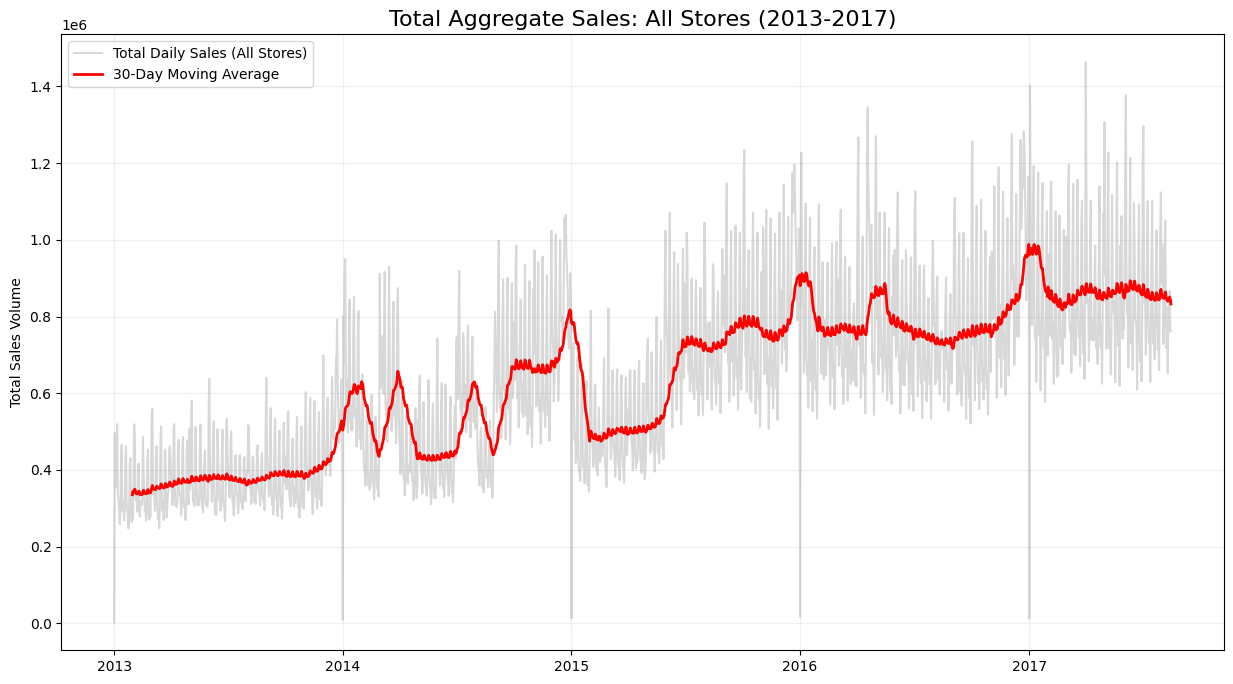

In [63]:
plt.figure(figsize=(15, 8))

# Plot Daily Totals (faded)
plt.plot(df_daily['date'], df_daily['sales'], alpha=0.3, color='gray', label='Total Daily Sales (All Stores)')

# Plot 30-Day National Trend
plt.plot(df_daily['date'], df_daily['national_trend_30d'], color='red', linewidth=2, label='30-Day Moving Average')

plt.title("Total Aggregate Sales: All Stores (2013-2017)", fontsize=16)
plt.ylabel("Total Sales Volume")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [64]:
# Define the split date
split_date = '2017-01-01'

# Split the data
train = df_merged[df_merged['date'] < split_date].copy()
val = df_merged[df_merged['date'] >= split_date].copy()

train = train.dropna()
val = val.dropna()
# Define Features (X) and Target (y)
# Exclude 'date', 'sales', and any raw IDs that don't help the model
features = [
    'store_nbr', 'family', 'onpromotion', 'dcoilwtico',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend',
    'lag_7', 'rolling_mean_7', 'rolling_mean_30', 'oil_rolling_7','oil_lag_7'
]

X_train = train[features]
y_train = train['sales']

X_val = val[features]
y_val = val['sales']

# Categorical Variables (family) need to be encoded
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['family'] = le.fit_transform(X_train['family'])
X_val['family'] = le.transform(X_val['family'])

# Transform the target
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)




/tmp/ipykernel_36003/3317992591.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['family'] = le.fit_transform(X_train['family'])
/tmp/ipykernel_36003/3317992591.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val['family'] = le.transform(X_val['family'])


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,mean_absolute_error

# 1. Separate Features
num_features = ['onpromotion', 'dcoilwtico', 'oil_rolling_7', 'lag_7',
                'rolling_mean_7', 'rolling_mean_30', 'month_sin', 'month_cos',
                'dow_sin', 'dow_cos', 'is_weekend','oil_lag_7']
cat_features = ['family', 'store_nbr']

# 2. Build the Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# 3. Create the Full Pipeline
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


In [66]:
# Train the model
lr_model.fit(X_train, np.log1p(y_train))

# Make Predictions
y_pred_log = lr_model.predict(X_val)

# Convert back from Log to Real Sales
# clip(0) ensures no negative values if the linear math goes slightly off
y_pred = np.expm1(y_pred_log).clip(0)


In [67]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
def mae(y_true, y_pred):
    return mean_absolute_error(y_true,y_pred)
print(f"Linear Regression RMSE: {rmse(y_val, y_pred):.4f}")
print(f"Linear Regression MAE: {mae(y_val, y_pred):.4f}")


Linear Regression RMSE: 103998.1413
Linear Regression MAE: 4996.1521


In [68]:
!pip install XGBoost

In [69]:
from xgboost import XGBRegressor

# Initialize the model
# tree_method='hist' or 'gpu_hist' makes training much faster on large datasets
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    objective='reg:squarederror', # We are predicting a continuous number (log_sales)
    early_stopping_rounds=25
)

# Fit the model
# We use the log-transformed target we created earlier
xgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=50,
)

# Predict on the validation set
y_pred_log_xgb = xgb_model.predict(X_val)

# Convert back to original scale
y_pred_xgb = np.expm1(y_pred_log_xgb).clip(0)

# Calculate the RMSLE
xgb_rmse = rmse(y_val, y_pred_xgb)
xgb_mae = mae(y_val,y_pred_xgb)
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")


[0]	validation_0-rmse:2.50704
[50]	validation_0-rmse:0.43428
[100]	validation_0-rmse:0.39755
[109]	validation_0-rmse:0.39769
XGBoost RMSE: 306.1766
XGBoost MAE: 73.2635


# Diagnostics

As we can see here it's way better so we will plot and visualize it

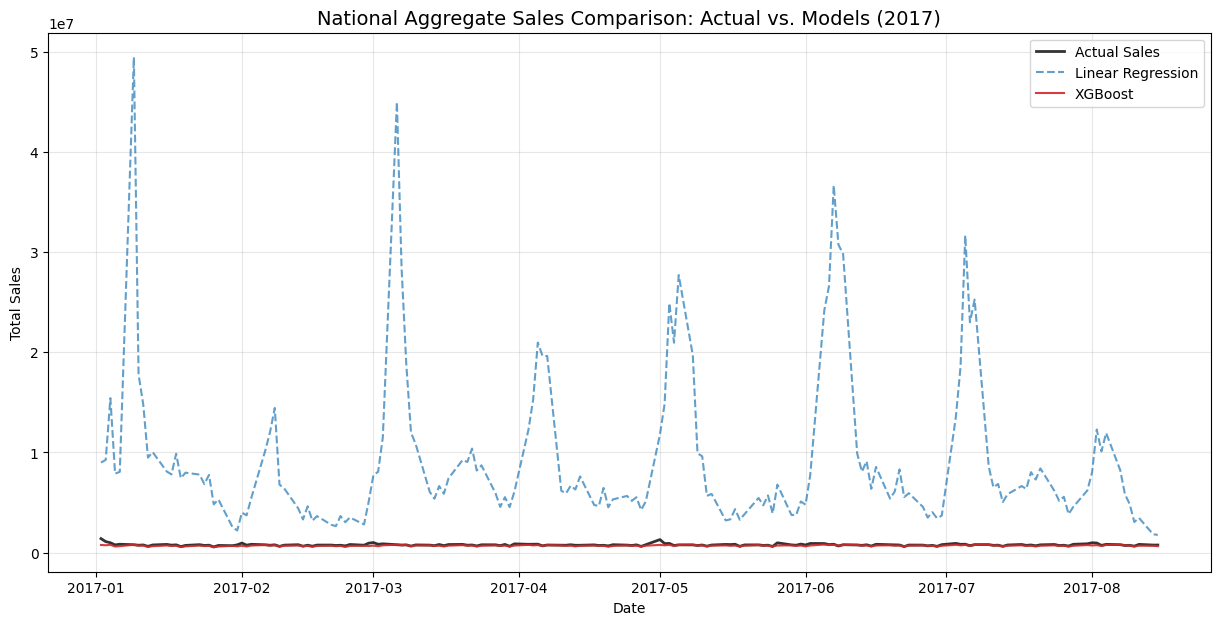

In [70]:
# Create a results dataframe for the validation period
results = val[['date', 'store_nbr', 'family', 'sales']].copy()
results['pred_lr'] = y_pred
results['pred_xgb'] = y_pred_xgb

# Aggregate by date for the "National" view
daily_results = results.groupby('date').agg({
    'sales': 'sum',
    'pred_lr': 'sum',
    'pred_xgb': 'sum'
}).reset_index()


plt.figure(figsize=(15, 7))

# Actual Sales
plt.plot(daily_results['date'], daily_results['sales'],
         label='Actual Sales', color='black', linewidth=2, alpha=0.8)

# Linear Regression Predictions
plt.plot(daily_results['date'], daily_results['pred_lr'],
         label='Linear Regression', color='tab:blue', linestyle='--', alpha=0.7)

# XGBoost Predictions
plt.plot(daily_results['date'], daily_results['pred_xgb'],
         label='XGBoost', color='tab:red', linewidth=1.5, alpha=0.9)

plt.title("National Aggregate Sales Comparison: Actual vs. Models (2017)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we can see here the linear regression is actuall so bad probably from the one hot encoding so i will try Ridge

In [71]:
from sklearn.linear_model import RidgeCV

# Create the Full Pipeline
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RidgeCV())
])
# Train the model
ridge_model.fit(X_train, np.log1p(y_train))

# Make Predictions
y_pred_log = ridge_model.predict(X_val)

# Convert back from Log to Real Sales
# clip(0) ensures no negative values if the linear math goes slightly off
y_pred = np.expm1(y_pred_log).clip(0)


print(f"Ridge Regression RMSE: {rmse(y_val, y_pred):.4f}")
print(f"Ridge Regression MAE: {mae(y_val, y_pred):.4f}")



Ridge Regression RMSE: 103984.4566
Ridge Regression MAE: 4995.7190


Still so bad for some reason i don't know

Maybe because of the one-hot encoding increasing the nuber features by so much making it unable to understand the system

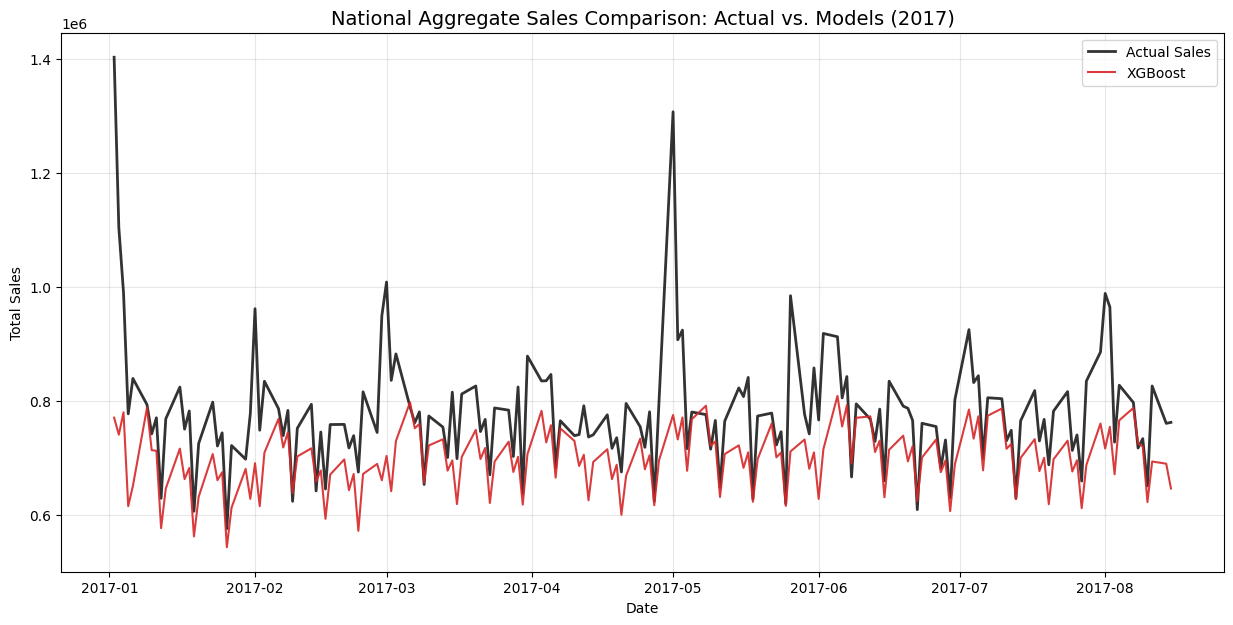

In [72]:
results = val[['date', 'store_nbr', 'family', 'sales']].copy()
results['pred_lr'] = y_pred
results['pred_xgb'] = y_pred_xgb

# Aggregate by date for the "National" view
daily_results = results.groupby('date').agg({
    'sales': 'sum',
    'pred_xgb': 'sum'
}).reset_index()


plt.figure(figsize=(15, 7))

# Actual Sales
plt.plot(daily_results['date'], daily_results['sales'],
         label='Actual Sales', color='black', linewidth=2, alpha=0.8)

# XGBoost Predictions
plt.plot(daily_results['date'], daily_results['pred_xgb'],
         label='XGBoost', color='tab:red', linewidth=1.5, alpha=0.9)

plt.title("National Aggregate Sales Comparison: Actual vs. Models (2017)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we can see it's good but it's so flat like it's unable to follow the heartbeat shape correctly maybe that's because i am using np.log1p to train it i will try using tweedie because it's made for a right-skewed data

In [73]:
from xgboost import XGBRegressor

# Initialize the model
# tree_method='hist' or 'gpu_hist' makes training much faster on large datasets
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    objective='reg:tweedie', # Changed into tweedie so we can deal with the skewness
    early_stopping_rounds=25
)

# Fit the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val,y_val)],
    verbose=50,
)

# Predict on the validation set
y_pred_xgb = xgb_model.predict(X_val)

# Calculate the RMSLE
xgb_rmse = rmse(y_val, y_pred_xgb)
xgb_mae = mae(y_val,y_pred_xgb)
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")


[0]	validation_0-tweedie-nloglik@1.5:82.51851
[50]	validation_0-tweedie-nloglik@1.5:50.23353
[100]	validation_0-tweedie-nloglik@1.5:49.60473
[150]	validation_0-tweedie-nloglik@1.5:49.57444
[190]	validation_0-tweedie-nloglik@1.5:49.58851
XGBoost RMSE: 253.9174
XGBoost MAE: 62.2264


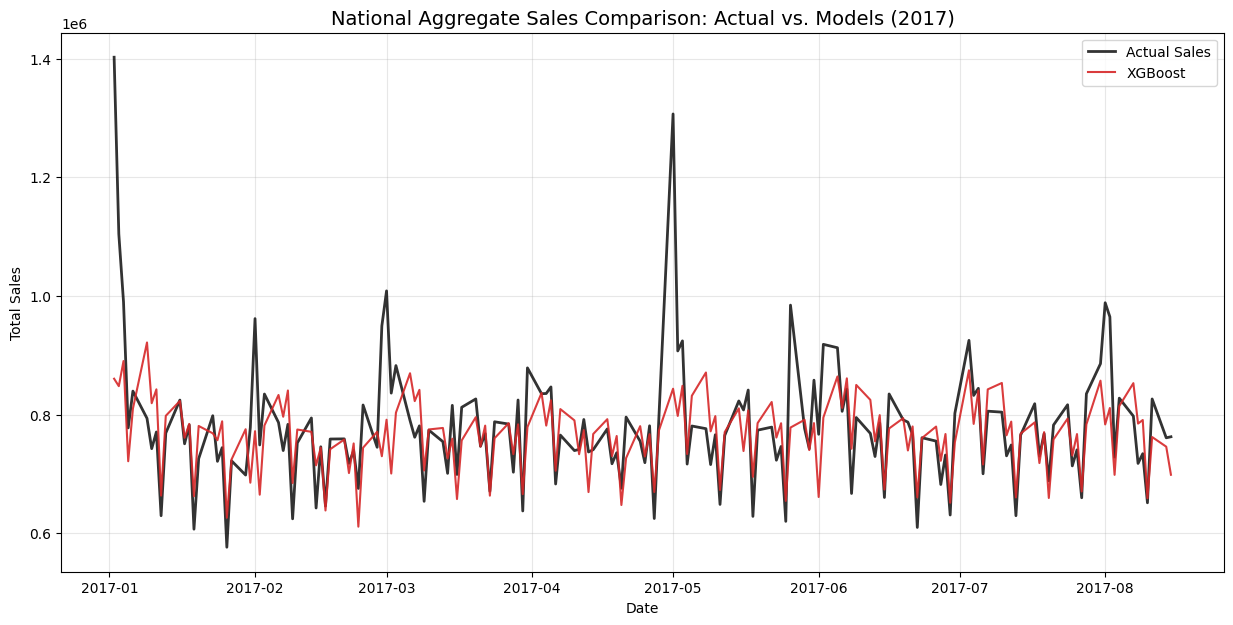

In [74]:
results = val[['date', 'store_nbr', 'family', 'sales']].copy()
results['pred_xgb'] = y_pred_xgb

# Aggregate by date for the "National" view
daily_results = results.groupby('date').agg({
    'sales': 'sum',
    'pred_xgb': 'sum'
}).reset_index()


plt.figure(figsize=(15, 7))

# Actual Sales
plt.plot(daily_results['date'], daily_results['sales'],
         label='Actual Sales', color='black', linewidth=2, alpha=0.8)

# XGBoost Predictions
plt.plot(daily_results['date'], daily_results['pred_xgb'],
         label='XGBoost', color='tab:red', linewidth=1.5, alpha=0.9)

plt.title("National Aggregate Sales Comparison: Actual vs. Models (2017)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

It's following the actual data better but it's unable to the spikes before each month maybe that's because the payday? like if i just recives my pay i will buy something and maybe because of holidays too i will add both of these

In [75]:
df_holidays = pd.read_csv(path+'/holidays_events.csv')
df_holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [76]:
# Filter for only 'National' holidays to start (or include Regional/Local later)
# Handle Transferred: If 'transferred' is True, we should ignore that row
#    because the actual event happened on a different date (Type 'Transfer')
holidays = df_holidays[df_holidays['transferred'] == False]

# Create a simple mapping of national holiday dates
national_holidays = holidays[holidays['locale'] == 'National']['date'].unique()

# Add the feature to your merged dataframe
df_merged['is_holiday'] = df_merged['date'].isin(national_holidays).astype(int)
# Add the is_payday to try to solve the spike around each end of the month
df_merged['is_payday'] = ((df_merged['date'].dt.day == 15) | (df_merged['date'].dt.is_month_end)).astype(int)


/tmp/ipykernel_36003/681022531.py:10: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_merged['is_holiday'] = df_merged['date'].isin(national_holidays).astype(int)


In [77]:
df_merged.head()

,id,date,store_nbr,family,sales,onpromotion,sales_moving_avg,dcoilwtico,year,is_weekend,...,dow_sin,dow_cos,lag_7,rolling_mean_7,rolling_mean_30,oil_lag_7,oil_rolling_7,oil_price_shock,is_holiday,is_payday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,67.662714,2013,0,...,0.781831,0.623490,NaN,0.000000,0.000000,NaN,67.662714,0.000000,1,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,0.285714,93.140000,2013,0,...,0.974928,-0.222521,NaN,1.000000,1.000000,NaN,80.401357,12.738643,0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,109.500857,92.970000,2013,0,...,0.433884,-0.900969,NaN,1.666667,1.666667,NaN,84.590905,8.379095,0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,86.213714,93.120000,2013,0,...,-0.433884,-0.900969,NaN,2.000000,2.000000,NaN,86.723179,6.396821,0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,57.953143,NaN,2013,1,...,-0.974928,-0.222521,NaN,2.600000,2.600000,NaN,86.723179,NaN,1,0


In [78]:
# Define the split date
split_date = '2017-01-01'

# Split the data
train = df_merged[df_merged['date'] < split_date].copy()
val = df_merged[df_merged['date'] >= split_date].copy()

train = train.dropna()
val = val.dropna()
# Define Features (X) and Target (y)
# Exclude 'date', 'sales', and any raw IDs that don't help the model
features = [
    'store_nbr', 'family', 'onpromotion', 'dcoilwtico',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend',
    'lag_7', 'rolling_mean_7', 'rolling_mean_30', 'oil_rolling_7','is_holiday',
    'is_payday'
]

X_train = train[features]
y_train = train['sales']

X_val = val[features]
y_val = val['sales']

# Categorical Variables (family) need to be encoded
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['family'] = le.fit_transform(X_train['family'])
X_val['family'] = le.transform(X_val['family'])

# Transform the target
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)




/tmp/ipykernel_36003/3262734123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['family'] = le.fit_transform(X_train['family'])
/tmp/ipykernel_36003/3262734123.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val['family'] = le.transform(X_val['family'])


In [79]:

# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    objective='reg:tweedie', # Changed into tweedie so we can deal with the skewness
    early_stopping_rounds=10
)

# Fit the model
# We use the log-transformed target we created earlier
xgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=50,
)

# Predict on the validation set
y_pred_log_xgb = xgb_model.predict(X_val)

# Convert back to original scale
y_pred_xgb = np.expm1(y_pred_log_xgb).clip(0)

# Calculate the RMSLE
xgb_rmse = rmse(y_val, y_pred_xgb)
xgb_mae = mae(y_val,y_pred_xgb)
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")


[0]	validation_0-tweedie-nloglik@1.5:7.49273
[50]	validation_0-tweedie-nloglik@1.5:6.76624
[100]	validation_0-tweedie-nloglik@1.5:6.74246
[124]	validation_0-tweedie-nloglik@1.5:6.74194
XGBoost RMSE: 329.6213
XGBoost MAE: 72.8025


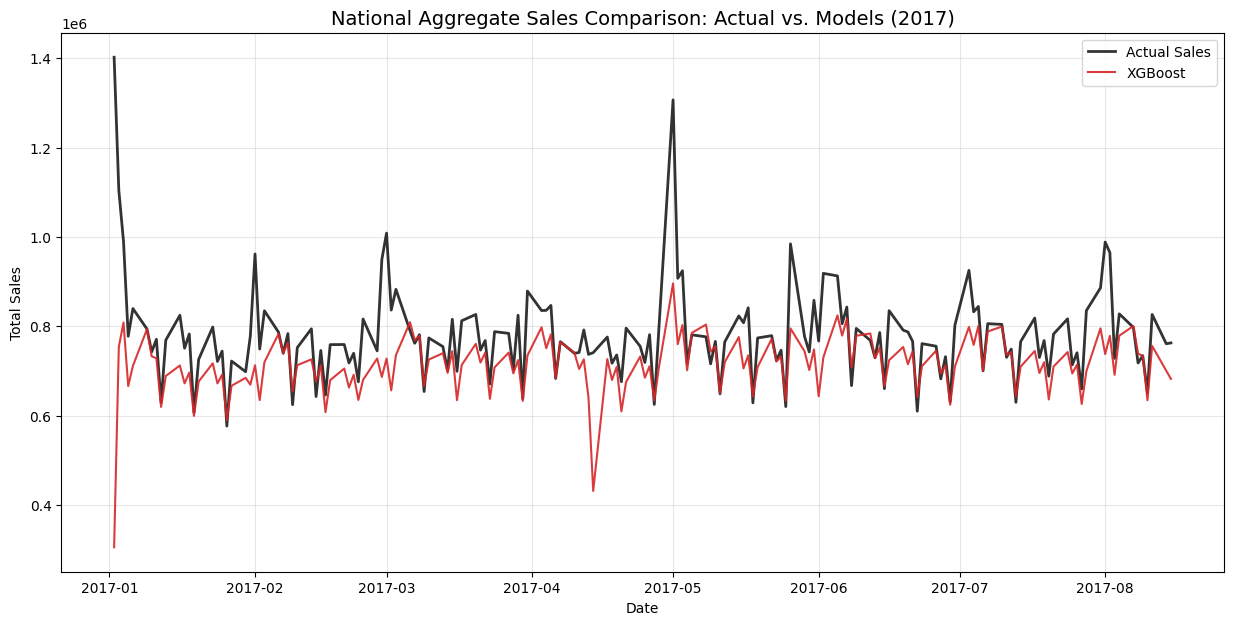

In [80]:
results = val[['date', 'store_nbr', 'family', 'sales']].copy()
results['pred_xgb'] = y_pred_xgb

# Aggregate by date for the "National" view
daily_results = results.groupby('date').agg({
    'sales': 'sum',
    'pred_xgb': 'sum'
}).reset_index()


plt.figure(figsize=(15, 7))

# Actual Sales
plt.plot(daily_results['date'], daily_results['sales'],
         label='Actual Sales', color='black', linewidth=2, alpha=0.8)

# XGBoost Predictions
plt.plot(daily_results['date'], daily_results['pred_xgb'],
         label='XGBoost', color='tab:red', linewidth=1.5, alpha=0.9)

plt.title("National Aggregate Sales Comparison: Actual vs. Models (2017)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

From what i can see it's following even more but the it's still can't see the sharpness

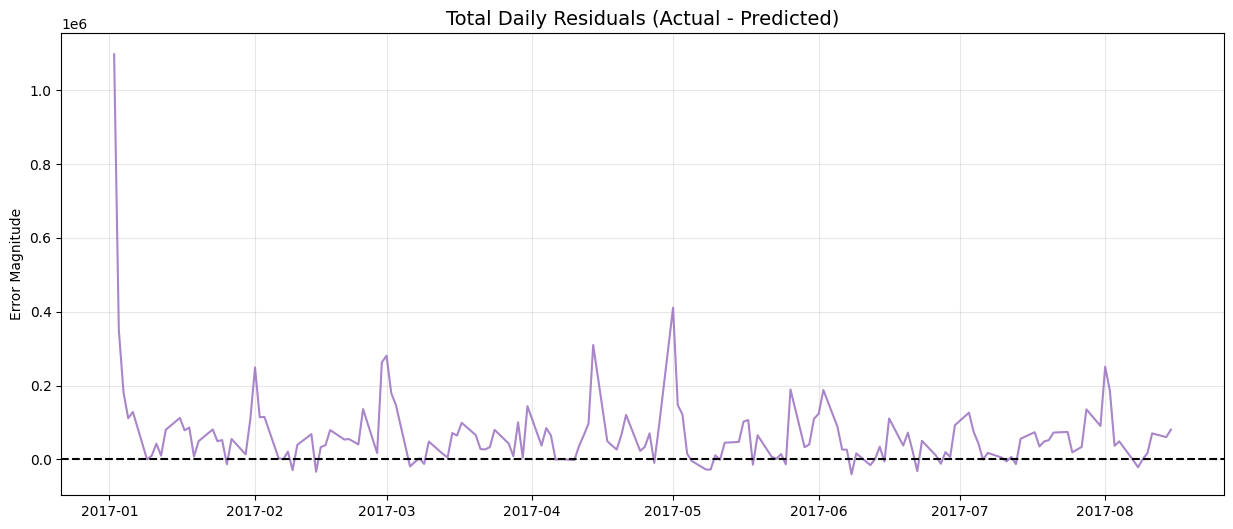

In [81]:
# Get predictions (ensure they are back in original scale)
y_pred_xgb = np.expm1(xgb_model.predict(X_val)).clip(0)

# Create a residuals dataframe
df_res = val[['date', 'store_nbr', 'family', 'sales']].copy()
df_res['pred'] = y_pred_xgb
df_res['residual'] = df_res['sales'] - df_res['pred']

import matplotlib.pyplot as plt

daily_res = df_res.groupby('date')['residual'].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(daily_res['date'], daily_res['residual'], color='tab:purple', alpha=0.8)
plt.axhline(0, color='black', linestyle='--')
plt.title("Total Daily Residuals (Actual - Predicted)", fontsize=14)
plt.ylabel("Error Magnitude")
plt.grid(True, alpha=0.3)
plt.show()

From what i can see the resiudals at the begining of the year is very problematic and then at each month there's a spike i tried to solve by having payday but it seems not like it also i think if made day_of_month instead of day_of_week and made the batch each month and sent it to LSTM i will be able to solve this problem but the dataset is large and i feel like training will take a lot of time

Of course the XGBoost perform way better i went to check LR again but i couldn't find the problem

# Questions
1. A time series is made to predict events usually done by using information from before to predict it so if it's random split the model might not see the patteren when training espically if i am using something like LSTM


2. I dropped them the tradeoff that i lost some data but no problem as it's not that trobling

3. I used hard date to split the data that would need to change and make it using time to get the current day and making offset also i lag 7 and rolling 30 should be calculated daily (or before the update), also i used onehotencoder which i will change to target encoding so if new stores or new category is added

this is the pipeline that was made

In [82]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

def ingest_data():
    """ Load raw data from sources"""
    train = pd.read_csv(path+'/train.csv', parse_dates=['date'])
    stores = pd.read_csv(path+'/stores.csv')
    oil = pd.read_csv(path+'/oil.csv', parse_dates=['date'])
    holidays = pd.read_csv(path+'/holidays_events.csv', parse_dates=['date'])
    return train, stores, oil, holidays

def merge_and_clean(train, stores, oil, holidays):
    """ Core Merging Logic"""
    # Fix oil missing values first
    oil = oil.set_index('date').resample('D').mean().interpolate().reset_index()

    # Merging
    df = train.merge(stores, on='store_nbr', how='left')
    df = df.merge(oil, on='date', how='left')

    # Holiday Logic: Only take non-transferred national holidays for simplicity
    nat_holidays = holidays[(holidays['locale'] == 'National') & (holidays['transferred'] == False)].copy()

    # Rename 'type' in nat_holidays to 'holiday_type' to avoid conflict with store 'type'
    nat_holidays.rename(columns={'type': 'holiday_type'}, inplace=True)

    df = df.merge(nat_holidays[['date', 'holiday_type']], on='date', how='left')
    df['is_holiday'] = df['holiday_type'].notna().astype(int)
    # Drop the temporary 'holiday_type' column if only the 'is_holiday' flag is needed
    df.drop(columns=['holiday_type'], inplace=True)
    return df

def feature_engineering(df):
    """ Improved Feature Engineering with Cold-Start handling """
    # 1. Sort for time-series consistency
    df = df.sort_values(['store_nbr', 'family', 'date'])

    # 2. Time Features
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_payday'] = ((df['date'].dt.day == 15) | (df['date'].dt.is_month_end)).astype(int)

    # 3. Cyclical encoding
    df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

    # 4. Rolling Windows with min_periods=1 (No more NaNs here)
    # This ensures we get a value even if we only have 1 day of history
    df['rolling_mean_7'] = df.groupby(['store_nbr', 'family'])['sales']\
                             .transform(lambda x: x.rolling(window=7, min_periods=1).mean())

    # 5. Oil Lag (Shifted by 7 days)
    df['oil_lag_7'] = df['dcoilwtico'].shift(7)
    # Fill oil cold-start with the first available price
    df['oil_lag_7'] = df['oil_lag_7'].fillna(method='bfill')

    # 6. Sales Lag with Explicit Cold-Start Handling
    df['lag_7'] = df.groupby(['store_nbr', 'family'])['sales'].shift(7)


    # If lag_7 is NaN, we use the global average of that family for that day of week.
    # This gives the model a 'typical' value for new stores.
    family_dow_avg = df.groupby(['family', 'day_of_week'])['sales'].transform('mean')
    df['lag_7'] = df['lag_7'].fillna(family_dow_avg)

    # FINAL SAFETY: If still NaN (rare), fill with 0
    df = df.fillna(0)

    return df

def preprocess_and_split(df, target_log=True):
    """ Encoding and Splitting without dropping data """
    le = LabelEncoder()

    # Identify Split Point
    last_date = df['date'].max()
    split_date = last_date - pd.Timedelta(days=15)

    # We must copy to avoid SettingWithCopyWarning
    train_df = df[df['date'] < split_date].copy()
    test_df = df[df['date'] >= split_date].copy()

    # Define Features
    features = [
        'store_nbr', 'family', 'onpromotion', 'dcoilwtico', 'is_weekend',
        'is_holiday', 'is_payday', 'month_sin', 'month_cos',
        'lag_7', 'rolling_mean_7', 'oil_lag_7'
    ]

    # Fit on train, transform on test
    train_df['family'] = le.fit_transform(train_df['family'])
    test_df['family'] = le.transform(test_df['family'])

    X_train, y_train = train_df[features], train_df['sales']
    X_test, y_test = test_df[features], test_df['sales']

    if target_log:
        y_train = np.log1p(y_train)
        y_test = np.log1p(y_test)

    return X_train, y_train, X_test, y_test, le

def train_pipeline():
    """Execution Loop"""
    # 1. Ingest
    t, s, o, h = ingest_data()
    # 2. Merge
    df = merge_and_clean(t, s, o, h)
    # 3. Features
    df = feature_engineering(df)
    # 4. Split
    X_train, y_train, X_test, y_test, label_encoder = preprocess_and_split(df)

    # 5. Model
    model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=8, n_jobs=-1, early_stopping_rounds=15)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    return model, label_encoder , X_test,y_test

In [83]:
model , le,X_test,y_test = train_pipeline()

/tmp/ipykernel_36003/3626815773.py:57: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['oil_lag_7'] = df['oil_lag_7'].fillna(method='bfill')


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_pred_log_xgb = model.predict(X_test)

# Convert back to original scale
y_pred_xgb = np.expm1(y_pred_log_xgb).clip(0)

#fuction to calculate
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
def mae(y_true, y_pred):
    return mean_absolute_error(y_true,y_pred)

# Calculate the RMSLE
xgb_rmse = rmse(y_test, y_pred_xgb)
xgb_mae = mae(y_test,y_pred_xgb)
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")
